# Lab 8 — ¿Se reemplaza tu entidad?

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Sesión 8: ¿Se reemplaza tu entidad?

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Cuatro partes. Es la primera vez que el curso **cruza dos entregas tuyas**: la
fecundidad del lab 7 y la tabla de vida del lab 4. De ahí salen la TBR, la TNR y
**tu propia TGF de reemplazo** — la que aplica a tu entidad, no el 2.1 de
manual.

**Antes de empezar, una advertencia sobre los datos de práctica:** la entidad de
práctica tiene exactamente la **misma TGF y la misma TBR que el país**. Si te
quedas ahí, la conclusión es «igual que el país». La parte 4 te va a pedir la
otra mitad.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTIDAD = "Baja California"   # <- tu entidad
FUENTE  = "Natalidad: INEGI/CONAPO, estimaciones 2023 (lab 7). Mortalidad y población femenina: CONAPO, Conciliación Demográfica 1950-2015 y Proyecciones de la Población 2016-2050 (defunciones y población, 2023)"   # <- fuentes: natalidad, mortalidad y poblacion (INEGI/CONAPO, año)

## Datos y herramienta

Dos insumos, los dos tuyos:

1. Las **tasas específicas de fecundidad** ₅fₓ de los siete grupos de 15 a 49
   — las calculaste en el lab 7.
2. Las **tasas de mortalidad femenina** ₅Mₓ en grupos quinquenales de 0 a 49
   — de tu fuente de mortalidad, ahora **solo mujeres** y en grupos de 5 años.

La función `tabla_femenina()` construye la tabla de vida de mujeres y devuelve
directamente lo único que hace falta hoy: la columna de supervivencia
₅Lₓ / (5·l₀) para los siete grupos fértiles.

In [37]:
GRUPOS_F = ['15-19','20-24','25-29','30-34','35-39','40-44','45-49']
GRUPOS_M = ['0-4','5-9','10-14'] + GRUPOS_F          # los 10 grupos de la tabla
MEDIO    = np.array([17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5])
ANCHO    = 5
RAIZ     = 100_000
FRAC_NINAS = 100 / 205        # razon de sexos al nacer: 105 ninos por 100 ninas

# --- referencia NACIONAL ---------------------------------------------------
F_NACIONAL = np.array([0.0700, 0.1150, 0.1050, 0.0800, 0.0400, 0.0090, 0.0005])
M_NACIONAL = np.array([0.00240, 0.00018, 0.00020, 0.00035, 0.00050,
                       0.00060, 0.00080, 0.00110, 0.00170, 0.00260])

# --- datos de PRACTICA (ilustrativos, no reales) ---------------------------
F_PRACTICA = np.array([0.0850, 0.1250, 0.1000, 0.0700, 0.0320, 0.0070, 0.0005])
M_PRACTICA = np.array([0.00480, 0.00036, 0.00040, 0.00070, 0.00100,
                       0.00120, 0.00160, 0.00220, 0.00340, 0.00520])


def tabla_femenina(nMx, raiz=RAIZ):
    """Tabla de vida de mujeres en 10 grupos quinquenales (0-4 .. 45-49).

    Devuelve (DataFrame completo, supervivencia de los 7 grupos fertiles),
    donde la supervivencia es 5Lx / (5*l0): la proporcion de una cohorte de
    recien nacidas que esta viva EN ALGUN MOMENTO de ese grupo de edad.
    Se usa 5Lx y no lx porque la fecundidad ocurre A LO LARGO del intervalo.
    """
    m = np.asarray(nMx, dtype=float)
    k = len(m)
    nqx = ANCHO * m / (1 + (ANCHO / 2) * m)      # los 10 son cerrados
    lx = np.zeros(k + 1)
    lx[0] = raiz
    for i in range(k):
        lx[i + 1] = lx[i] * (1 - nqx[i])
    ndx = lx[:-1] * nqx
    nLx = ANCHO * lx[1:] + (ANCHO / 2) * ndx
    tab = pd.DataFrame({'grupo': GRUPOS_M, 'nMx': m, 'nqx': nqx,
                        'lx': lx[:-1], 'ndx': ndx, 'nLx': nLx})
    superv = nLx[3:10] / (ANCHO * raiz)
    return tab, superv

## Tus datos

Pega tus siete ₅fₓ (del lab 7) y tus diez ₅Mₓ femeninas. Si dejas alguna lista
vacía se usan las de práctica y el notebook lo dice.

In [38]:
# TODO 0: pega tus datos.
mis_f = [0.0500, 0.1000, 0.1000, 0.0700, 0.0350, 0.0090, 0.0005]     # 7 tasas de fecundidad, grupos 15-19 .. 45-49
mis_M = [0.001788, 0.000139, 0.000216, 0.000369, 0.000458,
         0.000521, 0.000655, 0.000954, 0.001490, 0.002403]     # 10 tasas de mortalidad FEMENINA, grupos 0-4 .. 45-49

if len(mis_f) == 0 or len(mis_M) == 0:
    mis_f, mis_M = F_PRACTICA, M_PRACTICA
    print("Usando los datos de PRACTICA. Sustituyelos por los de tu entidad.")
else:
    mis_f, mis_M = np.asarray(mis_f, float), np.asarray(mis_M, float)
    print(f"Usando datos propios: {ENTIDAD}")

assert len(mis_f) == 7 and len(mis_M) == 10, "Faltan grupos"


Usando datos propios: Baja California


## Parte 1 — La cadena de los tres números  *(2.5 puntos)*

$$\text{TGF} = \sum_x 5\,{}_5f_x
\qquad
\text{TBR} = \text{TGF}\times 0.4878
\qquad
\text{TNR} = \sum_x 5\,{}_5f_x \times 0.4878 \times \frac{{}_5L_x}{5\,l_0}$$

In [39]:
# TODO 1.1: calcula tu TGF (es la del lab 7: comprueba que coincide) y tu TBR.
TGF_LAB7 = 1.8225   # TGF reportada en el lab 7 para Baja California
tgf = ANCHO * mis_f.sum()
tbr = tgf * FRAC_NINAS
print(f"TGF de {ENTIDAD}: {tgf:.4f}  (lab 7: {TGF_LAB7:.4f}) -> ¿coincide?: {np.isclose(tgf, TGF_LAB7)}")
print(f"TBR de {ENTIDAD}: {tbr:.4f} hijas por mujer")

# TODO 1.2: construye tu tabla de vida femenina con tabla_femenina() y obten la
#   columna de supervivencia de los siete grupos fertiles. Imprimela.
tab_fem, superv = tabla_femenina(mis_M)
print("\nTabla de vida femenina (0-49):")
display(tab_fem)
print("\nSupervivencia 5Lx/(5*l0) en los grupos fértiles:")
for g, s_ in zip(GRUPOS_F, superv):
    print(f"  {g}: {s_:.5f}")

# TODO 1.3: calcula tu TNR sumando, grupo por grupo, el producto de los TRES
#   factores. Presenta la tabla con una columna por factor y la aportacion de
#   cada grupo, para que se vea de donde sale el total.
aport = (ANCHO * mis_f) * FRAC_NINAS * superv
tnr = aport.sum()
df_tnr = pd.DataFrame({'grupo': GRUPOS_F,
                       '5*5fx': ANCHO * mis_f,
                       'frac_ninas': FRAC_NINAS,
                       '5Lx/(5*l0)': superv,
                       'aportacion_TNR': aport})
display(df_tnr)
print(f"\nTNR de {ENTIDAD} = suma de las aportaciones = {tnr:.4f}")

TGF de Baja California: 1.8225  (lab 7: 1.8225) -> ¿coincide?: True
TBR de Baja California: 0.8890 hijas por mujer

Tabla de vida femenina (0-49):


,grupo,nMx,nqx,lx,ndx,nLx
0,0-4,0.001788,0.008900,100000.000000,890.021603,497774.945991
1,5-9,0.000139,0.000695,99109.978397,68.857507,495377.748215
2,10-14,0.000216,0.001079,99041.120890,106.906681,494938.337745
3,15-19,0.000369,0.001843,98934.214209,182.365393,494215.157560
4,20-24,0.000458,0.002287,98751.848815,225.883098,493194.536333
5,25-29,0.000521,0.002602,98525.965718,256.326276,491989.012900
6,30-34,0.000655,0.003270,98269.639442,321.306929,490544.929888
7,35-39,0.000954,0.004759,97948.332513,466.101893,488576.407832
8,40-44,0.001490,0.007422,97482.230620,723.547404,485602.284590
9,45-49,0.002403,0.011943,96758.683216,1155.613232,480904.382999



Supervivencia 5Lx/(5*l0) en los grupos fértiles:
  15-19: 0.98843
  20-24: 0.98639
  25-29: 0.98398
  30-34: 0.98109
  35-39: 0.97715
  40-44: 0.97120
  45-49: 0.96181


,grupo,5*5fx,frac_ninas,5Lx/(5*l0),aportacion_TNR
0,15-19,0.2500,0.487805,0.988430,0.120540
1,20-24,0.5000,0.487805,0.986389,0.240583
2,25-29,0.5000,0.487805,0.983978,0.239995
3,30-34,0.3500,0.487805,0.981090,0.167503
4,35-39,0.1750,0.487805,0.977153,0.083415
5,40-44,0.0450,0.487805,0.971205,0.021319
6,45-49,0.0025,0.487805,0.961809,0.001173



TNR de Baja California = suma de las aportaciones = 0.8745


## Parte 2 — Tu cohorte de 1,000 mujeres, y tu umbral  *(2.5 puntos)*

In [40]:
# TODO 2.1: traduce tus tres numeros a la cascada de 1,000 mujeres: cuantas
#   criaturas, cuantas ninas, y cuantas llegan a la edad de tener las suyas.
#   Imprimelo como tres renglones con sus nombres.
print(f"Cohorte de 1,000 mujeres de {ENTIDAD}:")
print(f"  Criaturas nacidas (TGF x 1000):                 {tgf*1000:,.0f}")
print(f"  Niñas nacidas (TBR x 1000):                     {tbr*1000:,.0f}")
print(f"  Niñas que llegan a la edad fértil (TNR x 1000): {tnr*1000:,.0f}")

# TODO 2.2: calcula tu supervivencia media ponderada p = TNR / TBR, y de ahi TU
#   TGF DE REEMPLAZO, 1 / (0.4878 * p). Compara ese umbral con el 2.1 de manual
#   y di si el tuyo esta por arriba o por abajo, y por que.
p = tnr / tbr
tgf_rep = 1 / (FRAC_NINAS * p)
print(f"\nSupervivencia media ponderada p = TNR/TBR = {p:.4f}")
print(f"TGF de reemplazo de {ENTIDAD} = 1/(0.4878 x p) = {tgf_rep:.4f}")
print(f"Comparado con el 2.1 de manual, mi umbral está por {'ABAJO' if tgf_rep < 2.1 else 'ARRIBA'} "
      f"({tgf_rep - 2.1:+.4f}).")
print("Está por abajo porque la mortalidad femenina de 0 a 49 años en Baja California es baja: "
      f"el {p*100:.2f}% de las niñas (ponderado por la fecundidad) sobrevive hasta la edad en que tendría "
      "a sus hijas. El 2.1 de manual incorpora un descuento por mortalidad más grande que el que "
      "realmente tiene la entidad, así que a Baja California le bastan menos hijos por mujer para reemplazarse.")

# TODO 2.3: haz lo mismo con los datos NACIONALES y pon las dos columnas juntas
#   —tu entidad y el pais— con TGF, TBR, TNR, p y TGF de reemplazo.
tgf_nac = ANCHO * F_NACIONAL.sum()
tbr_nac = tgf_nac * FRAC_NINAS
_, superv_nac = tabla_femenina(M_NACIONAL)
aport_nac = (ANCHO * F_NACIONAL) * FRAC_NINAS * superv_nac
tnr_nac = aport_nac.sum()
p_nac = tnr_nac / tbr_nac
tgf_rep_nac = 1 / (FRAC_NINAS * p_nac)

df_comp = pd.DataFrame({'Indicador': ['TGF', 'TBR', 'TNR', 'p (superv. media)', 'TGF de reemplazo'],
                        ENTIDAD: [tgf, tbr, tnr, p, tgf_rep],
                        'Nacional': [tgf_nac, tbr_nac, tnr_nac, p_nac, tgf_rep_nac]})
df_comp['Diferencia'] = df_comp[ENTIDAD] - df_comp['Nacional']
display(df_comp.round(4))

Cohorte de 1,000 mujeres de Baja California:
  Criaturas nacidas (TGF x 1000):                 1,822
  Niñas nacidas (TBR x 1000):                     889
  Niñas que llegan a la edad fértil (TNR x 1000): 875

Supervivencia media ponderada p = TNR/TBR = 0.9837
TGF de reemplazo de Baja California = 1/(0.4878 x p) = 2.0840
Comparado con el 2.1 de manual, mi umbral está por ABAJO (-0.0160).
Está por abajo porque la mortalidad femenina de 0 a 49 años en Baja California es baja: el 98.37% de las niñas (ponderado por la fecundidad) sobrevive hasta la edad en que tendría a sus hijas. El 2.1 de manual incorpora un descuento por mortalidad más grande que el que realmente tiene la entidad, así que a Baja California le bastan menos hijos por mujer para reemplazarse.


,Indicador,Baja California,Nacional,Diferencia
0,TGF,1.8225,2.0975,-0.2750
1,TBR,0.8890,1.0232,-0.1341
2,TNR,0.8745,1.0030,-0.1285
3,p (superv. media),0.9837,0.9803,0.0034
4,TGF de reemplazo,2.0840,2.0912,-0.0072


## Parte 3 — Verificación y ritmo  *(2.0 puntos)*

La cadena tiene que cumplir **siempre** TNR ≤ TBR ≤ TGF, y las razones entre
ellas no son cualquier cosa: la primera es 0.4878 exacto y la segunda es tu
supervivencia media. Si alguna sale al revés, hay un error.

TNR (0.8745) <= TBR (0.8890) <= TGF (1.8225): True
TBR/TGF = 0.4878 -> ¿es 0.4878?: True
TNR/TBR = 0.9837 = p (supervivencia media): True
Nacional -> TNR <= TBR <= TGF: True; TBR/TGF = 0.4878

Longitud media de generación T de Baja California: 27.05 años
Tasa intrínseca r = ln(0.8745)/27.05 = -4.96 por mil por año
Nacional: T = 26.68 años, r = 0.11 por mil por año


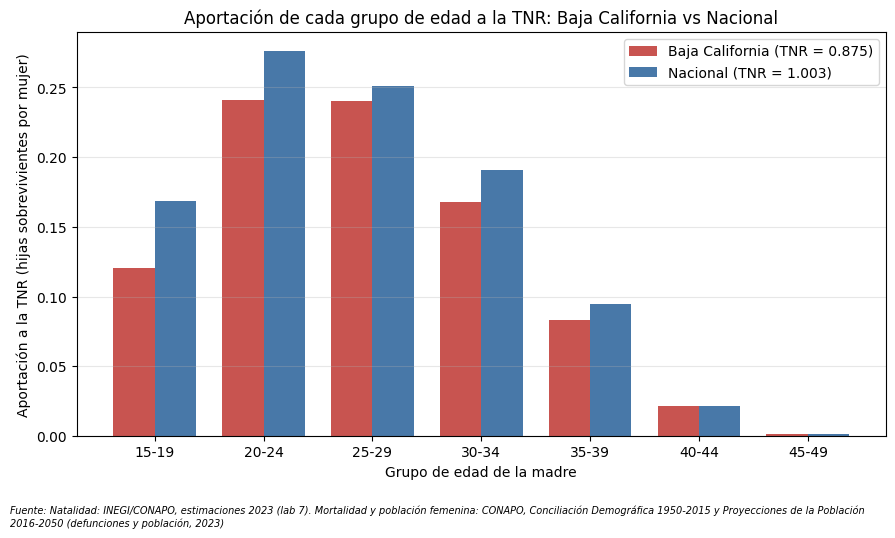

In [41]:
# TODO 3.1: verifica EN CODIGO las dos cosas: que TNR <= TBR <= TGF, y que
#   TBR/TGF da 0.4878. Imprime el resultado de cada comprobacion.
orden_ok = (tnr <= tbr) and (tbr <= tgf)
razon_ok = np.isclose(tbr / tgf, 0.4878, atol=1e-4)
print(f"TNR ({tnr:.4f}) <= TBR ({tbr:.4f}) <= TGF ({tgf:.4f}): {orden_ok}")
print(f"TBR/TGF = {tbr/tgf:.4f} -> ¿es 0.4878?: {razon_ok}")
print(f"TNR/TBR = {tnr/tbr:.4f} = p (supervivencia media): {np.isclose(tnr/tbr, p)}")
print(f"Nacional -> TNR <= TBR <= TGF: {(tnr_nac <= tbr_nac) and (tbr_nac <= tgf_nac)}; "
      f"TBR/TGF = {tbr_nac/tgf_nac:.4f}")

# TODO 3.2: calcula tu longitud media de generacion T —la edad media ponderada
#   por las hijas SOBREVIVIENTES— y de ahi tu tasa intrinseca
#   r = ln(TNR)/T. Reportala por mil y por anio.
T = (MEDIO * aport).sum() / aport.sum()
r_int = np.log(tnr) / T
T_nac = (MEDIO * aport_nac).sum() / aport_nac.sum()
r_nac = np.log(tnr_nac) / T_nac
print(f"\nLongitud media de generación T de {ENTIDAD}: {T:.2f} años")
print(f"Tasa intrínseca r = ln({tnr:.4f})/{T:.2f} = {r_int*1000:.2f} por mil por año")
print(f"Nacional: T = {T_nac:.2f} años, r = {r_nac*1000:.2f} por mil por año")

# TODO 3.3: grafica la aportacion de cada grupo de edad a la TNR, y encima (o al
#   lado) la del pais. Ejes etiquetados, leyenda y fuente.
x = np.arange(len(GRUPOS_F))
w = 0.38
plt.figure(figsize=(9, 5))
plt.bar(x - w/2, aport, width=w, label=f'{ENTIDAD} (TNR = {tnr:.3f})', color='#c85450')
plt.bar(x + w/2, aport_nac, width=w, label=f'Nacional (TNR = {tnr_nac:.3f})', color='#4878a8')
plt.xticks(x, GRUPOS_F)
plt.xlabel('Grupo de edad de la madre')
plt.ylabel('Aportación a la TNR (hijas sobrevivientes por mujer)')
plt.title(f'Aportación de cada grupo de edad a la TNR: {ENTIDAD} vs Nacional')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.figtext(0.01, -0.06, f'Fuente: {FUENTE}', fontsize=7, style='italic', wrap=True)
plt.tight_layout()
plt.show()

## Parte 4 — El argumento, con sus cuatro piezas  *(3.0 puntos)*

In [42]:
# TODO 4.1 — EL VEREDICTO
# Di si tu entidad se reemplaza, con tu TNR y contra que umbral la comparas.
# Cuida esto: el umbral de la TNR es 1, no 2.
print(f"TNR de {ENTIDAD}: {tnr:.4f}.")
print(f"{ENTIDAD} {'sí' if tnr >= 1 else 'no'} se reemplaza. Cada mujer deja, en promedio, "
      f"{tnr:.3f} hijas que sobreviven hasta la edad de tener las suyas; es decir, cada generación de "
      f"mujeres es un {(1 - tnr)*100:.1f}% más pequeña que la anterior (sin contar migración).")

TNR de Baja California: 0.8745.
Baja California no se reemplaza. Cada mujer deja, en promedio, 0.875 hijas que sobreviven hasta la edad de tener las suyas; es decir, cada generación de mujeres es un 12.5% más pequeña que la anterior (sin contar migración).


In [43]:
# TODO 4.2 — DE DONDE VIENE
# Compara tu entidad con el pais en las TRES cifras. Si tu TGF y tu TBR son
# parecidas a las nacionales y tu TNR no, la diferencia esta en la
# SUPERVIVENCIA: dilo con el numero (tu p contra la nacional) y di que significa.
print(f"TGF: {tgf:.4f} vs {tgf_nac:.4f} nacional (razón {tgf/tgf_nac:.4f})")
print(f"TBR: {tbr:.4f} vs {tbr_nac:.4f} nacional (razón {tbr/tbr_nac:.4f})")
print(f"TNR: {tnr:.4f} vs {tnr_nac:.4f} nacional (razón {tnr/tnr_nac:.4f})")
print(f"p:   {p:.4f} vs {p_nac:.4f} nacional (razón {p/p_nac:.4f})")
print(f"\nComo TNR = TGF x 0.4878 x p, la razón de las TNR se descompone en "
      f"{tgf/tgf_nac:.4f} (fecundidad) x {p/p_nac:.4f} (supervivencia) = {tnr/tnr_nac:.4f}.")
print("En Baja California, la diferencia no viene de la supervivencia: la TGF y la TBR de Baja California ya son "
      f"un {(1 - tgf/tgf_nac)*100:.1f}% más bajas que las nacionales, y esa brecha pasa casi entera a la TNR. "
      f"La supervivencia incluso juega a favor: p = {p:.4f} contra {p_nac:.4f} nacional, o sea que de cada "
      f"1,000 niñas nacidas en Baja California llegan a la edad fértil unas {(p - p_nac)*1000:.1f} más que en el país, "
      "porque la mortalidad femenina de 0 a 49 años es menor (sobre todo en 0-4). Esa ventaja es demasiado "
      "pequeña para compensar la menor fecundidad: la entidad no se reemplaza porque tiene pocos hijos, no porque se le mueran.")

TGF: 1.8225 vs 2.0975 nacional (razón 0.8689)
TBR: 0.8890 vs 1.0232 nacional (razón 0.8689)
TNR: 0.8745 vs 1.0030 nacional (razón 0.8719)
p:   0.9837 vs 0.9803 nacional (razón 1.0034)

Como TNR = TGF x 0.4878 x p, la razón de las TNR se descompone en 0.8689 (fecundidad) x 1.0034 (supervivencia) = 0.8719.
En Baja California, la diferencia no viene de la supervivencia: la TGF y la TBR de Baja California ya son un 13.1% más bajas que las nacionales, y esa brecha pasa casi entera a la TNR. La supervivencia incluso juega a favor: p = 0.9837 contra 0.9803 nacional, o sea que de cada 1,000 niñas nacidas en Baja California llegan a la edad fértil unas 3.4 más que en el país, porque la mortalidad femenina de 0 a 49 años es menor (sobre todo en 0-4). Esa ventaja es demasiado pequeña para compensar la menor fecundidad: la entidad no se reemplaza porque tiene pocos hijos, no porque se le mueran.


In [44]:
# TODO 4.3 — TU UMBRAL, NO EL DE MANUAL
# Reporta tu TGF de reemplazo y explica por que NO es 2.1 exacto. Di cual de los
# dos descuentos —la fraccion de ninas o la supervivencia— es el que mueve TU
# umbral respecto al nacional, y por cuanto.
print(f"TGF de reemplazo de {ENTIDAD}: {tgf_rep:.4f} (nacional: {tgf_rep_nac:.4f}; manual: 2.1)")
print("No es 2.1 exacto porque el umbral sale de 1/(0.4878 x p): el 2.1 de manual es un redondeo que supone "
      "una supervivencia genérica, mientras que el mío usa la p calculada con la tabla de vida femenina de la entidad.")
print("Sin mortalidad (p = 1) el umbral sería 1/0.4878 = 2.05; la fracción de niñas explica ese 2.05 y es "
      "igual en la entidad y en el país (0.4878, 105 niños por 100 niñas), así que no mueve nada entre ambos.")
print(f"El descuento que mueve mi umbral respecto al nacional es la supervivencia: p = {p:.4f} contra {p_nac:.4f}, "
      f"lo que baja el umbral en {tgf_rep - tgf_rep_nac:+.4f} hijos por mujer ({(tgf_rep/tgf_rep_nac - 1)*100:+.2f}%).")
print(f"Aun con ese umbral más bajo, la TGF de {tgf:.4f} queda {tgf_rep - tgf:.4f} hijos por mujer por debajo del reemplazo.")

TGF de reemplazo de Baja California: 2.0840 (nacional: 2.0912; manual: 2.1)
No es 2.1 exacto porque el umbral sale de 1/(0.4878 x p): el 2.1 de manual es un redondeo que supone una supervivencia genérica, mientras que el mío usa la p calculada con la tabla de vida femenina de la entidad.
Sin mortalidad (p = 1) el umbral sería 1/0.4878 = 2.05; la fracción de niñas explica ese 2.05 y es igual en la entidad y en el país (0.4878, 105 niños por 100 niñas), así que no mueve nada entre ambos.
El descuento que mueve mi umbral respecto al nacional es la supervivencia: p = 0.9837 contra 0.9803, lo que baja el umbral en -0.0072 hijos por mujer (-0.34%).
Aun con ese umbral más bajo, la TGF de 1.8225 queda 0.2615 hijos por mujer por debajo del reemplazo.


In [45]:
# TODO 4.4 — EL LIMITE
# Elige DOS de los cuatro limites de la sesion —migracion, inercia demografica,
# efecto tempo, modelo de un solo sexo— y di, para cada uno, por que es
# relevante EN TU ENTIDAD en particular.
print("(1) MIGRACIÓN. La TNR describe una población cerrada, y Baja California es de las entidades más abiertas "
      "del país: es frontera con Estados Unidos, recibe migración interna constante hacia Tijuana y Mexicali y "
      "migración internacional en tránsito o de retorno. Con saldo migratorio positivo, la población puede seguir "
      f"creciendo aunque la TNR ({tnr:.3f}) sea menor que 1; además, parte de las mujeres que tienen hijos en la "
      "entidad nacieron y sobrevivieron en otro estado, así que su tabla de vida no es la de Baja California.")
print(f"\n(2) EFECTO TEMPO. En el lab 7 la edad media a la maternidad de la entidad (27.07 años) salió mayor que la "
      "nacional (26.71), con tasas adolescentes más bajas: hay señal de posposición de la maternidad. Una TGF de "
      "periodo medida mientras las mujeres retrasan sus embarazos se deprime temporalmente, y con ella la TBR y la TNR. "
      f"Parte de la distancia entre mi TGF ({tgf:.3f}) y mi umbral ({tgf_rep:.3f}) podría ser calendario y no "
      "cantidad; para distinguirlo habría que ver la descendencia final de cohortes completas.")

(1) MIGRACIÓN. La TNR describe una población cerrada, y Baja California es de las entidades más abiertas del país: es frontera con Estados Unidos, recibe migración interna constante hacia Tijuana y Mexicali y migración internacional en tránsito o de retorno. Con saldo migratorio positivo, la población puede seguir creciendo aunque la TNR (0.875) sea menor que 1; además, parte de las mujeres que tienen hijos en la entidad nacieron y sobrevivieron en otro estado, así que su tabla de vida no es la de Baja California.

(2) EFECTO TEMPO. En el lab 7 la edad media a la maternidad de la entidad (27.07 años) salió mayor que la nacional (26.71), con tasas adolescentes más bajas: hay señal de posposición de la maternidad. Una TGF de periodo medida mientras las mujeres retrasan sus embarazos se deprime temporalmente, y con ella la TBR y la TNR. Parte de la distancia entre mi TGF (1.823) y mi umbral (2.084) podría ser calendario y no cantidad; para distinguirlo habría que ver la descendencia final

## Cierre y entrega

**Checklist:**
- [ ] Mi TGF coincide con la del lab 7 (comprobado, no supuesto).
- [ ] La mortalidad que usé es **femenina** y en grupos de 5 años.
- [ ] La TNR usa ₅Lₓ/(5·l₀), no lₓ.
- [ ] La verificación TNR ≤ TBR ≤ TGF está **impresa**.
- [ ] Comparé la TNR contra **1**, no contra 2.
- [ ] Las cuatro piezas de la parte 4 están escritas por separado.

**Cómo se entrega:** en Colab, `Archivo → Descargar → Descargar .ipynb`, y
arrastra ese archivo al sistema. **El archivo, no el enlace.** Ejecuta el
notebook completo antes de subirlo.

Tienes **dos intentos**.